<a href="https://colab.research.google.com/github/amanvashisth/Deep-Learning/blob/master/feature_scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [3]:
import pandas as pd
import numpy as np

# Set seed so the same dataset is generated every time
np.random.seed(42)

# Generate 1000 rows
n = 1000

# Input features
age = np.random.randint(18, 61, n)
salary = np.random.randint(20000, 150001, n)

# Generate output feature
# Higher age and salary increase the probability of purchasing
purchase_probability = (
    0.3 * (age - 18) / (60 - 18)
    + 0.7 * (salary - 20000) / (150000 - 20000)
)

purchase = np.random.binomial(1, purchase_probability)

# Create DataFrame
df = pd.DataFrame({
    "age": age,
    "salary": salary,
    "purchase": purchase
})

# Display first 5 rows
print(df.head())

# Check shape
print(df.shape)

   age  salary  purchase
0   56  122916         1
1   46  132250         1
2   32  136553         0
3   60   63872         0
4   25   66197         1
(1000, 3)


In [4]:
df.head()

,age,salary,purchase
0,56,122916,1
1,46,132250,1
2,32,136553,0
3,60,63872,0
4,25,66197,1


In [5]:
import seaborn as sns

<Axes: xlabel='age', ylabel='salary'>

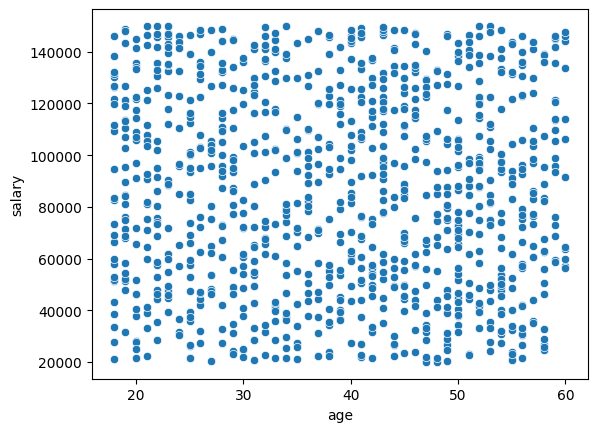

In [7]:
sns.scatterplot(x= df.iloc[:,0], y=df.iloc[:,1])

In [8]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [11]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [14]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4725 - loss: 332.1196 - val_accuracy: 0.4800 - val_loss: 145.3090
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5275 - loss: 88.8799 - val_accuracy: 0.4800 - val_loss: 117.3745
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4650 - loss: 88.7924 - val_accuracy: 0.5200 - val_loss: 192.5318
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4975 - loss: 133.6052 - val_accuracy: 0.4800 - val_loss: 77.1329
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4825 - loss: 50.3084 - val_accuracy: 0.5200 - val_loss: 128.9717
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4700 - loss: 161.2809 - val_accuracy: 0.5200 - val_loss: 65.2439
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4963 - loss: 109.0377 - val_accuracy: 0.5200 - val_loss: 101.8422
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4850 - loss: 65.0106 -

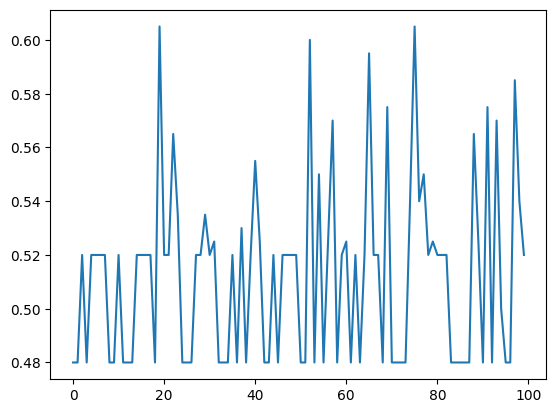

In [15]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

Applying Scaling


In [16]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
X_train_scaled

array([[ 0.79677301, -0.16030998],
       [-0.58591334, -0.47674553],
       [ 0.47143505, -1.05168544],
       ...,
       [-0.9925858 ,  1.06858113],
       [ 0.47143505, -0.79117718],
       [ 0.39010055, -1.64877245]])

<Axes: >

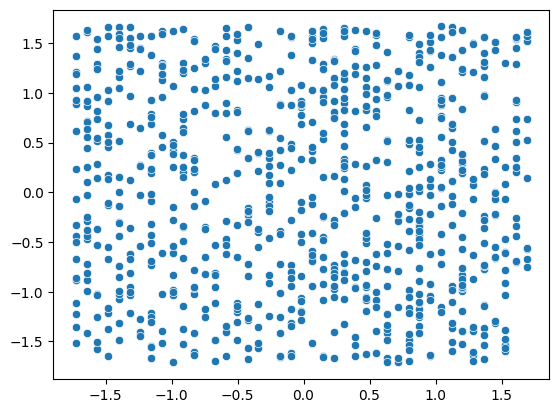

In [19]:
sns.scatterplot(x= X_train_scaled[:,0],y=X_train_scaled[:,1])

In [20]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.6737 - loss: 0.6568 - val_accuracy: 0.6900 - val_loss: 0.6299
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6862 - loss: 0.6120 - val_accuracy: 0.6950 - val_loss: 0.6046
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6888 - loss: 0.5921 - val_accuracy: 0.6950 - val_loss: 0.5950
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6913 - loss: 0.5839 - val_accuracy: 0.6950 - val_loss: 0.5919
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6888 - loss: 0.5820 - val_accuracy: 0.6950 - val_loss: 0.5913
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6875 - loss: 0.5812 - val_accuracy: 0.6950 - val_loss: 0.5920
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6850 - loss: 0.5805 - val_accuracy: 0.6950 - val_loss: 0.5920
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6925 - loss: 0.5804 - val_accuracy: 0.

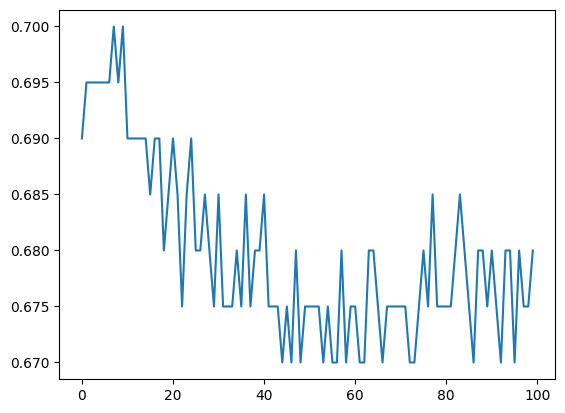

In [21]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])